In [1]:
import sqlite3

conn = sqlite3.connect("sales_data.db")
cursor = conn.cursor()

cursor.execute('''
    CREATE TABLE IF NOT EXISTS sales (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        product TEXT,
        quantity INTEGER,
        price REAL
    )
''')
# Insert some sample data
sample_data = [
    ('Laptop', 5, 60000),
    ('Mouse', 10, 500),
    ('Keyboard', 7, 1500),
    ('Monitor', 3, 12000),
    ('Laptop', 2, 60000),
    ('Mouse', 15, 500),
    ('Keyboard', 5, 1500)
]

cursor.executemany("INSERT INTO sales (product, quantity, price) VALUES (?, ?, ?)", sample_data)

# Commit and close
conn.commit()
conn.close()


Sales Summary:
     product  total_qty   revenue
0  Keyboard         12   18000.0
1    Laptop          7  420000.0
2   Monitor          3   36000.0
3     Mouse         25   12500.0


<Figure size 800x500 with 0 Axes>

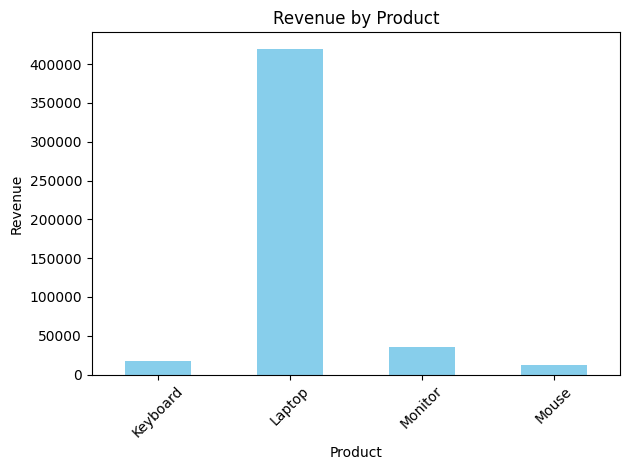

In [2]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# Reconnect to DB
conn = sqlite3.connect("sales_data.db")

# Write SQL query
query = """
SELECT
    product,
    SUM(quantity) AS total_qty,
    SUM(quantity * price) AS revenue
FROM sales
GROUP BY product
"""

# Load results into Pandas
df = pd.read_sql_query(query, conn)
print("Sales Summary:\n", df)

# Bar chart
plt.figure(figsize=(8,5))
df.plot(kind='bar', x='product', y='revenue', legend=False, color='skyblue')
plt.title('Revenue by Product')
plt.xlabel('Product')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("sales_chart.png")
plt.show()

# Close connection
conn.close()
